In [ ]:
import itertools
from typing import TypeAlias, Any, Callable, ParamSpec, Concatenate
from collections.abc import Sequence
import numpy as np
import numpy.random as npr
import numpy.typing as npt
from scipy import integrate as intg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pynumdiff as nd  # Some submodules requrie cvxpy or tqdm
from pynumdiff import smooth_finite_difference as smoothfd
import pysindy as ps
import sys

import importlib
import mysindy
importlib.reload(mysindy) # Force reloading module to apply changes

ModuleNotFoundError: No module named 'scipy'

In [ ]:
dt = 1e-3
num_steps = 1 * 10 ** 4

x_0 = np.array([0, 2, 8])
traj = mysindy.Trajectory(mysindy.lorenz, x_0, dt, num_steps, 0.1)

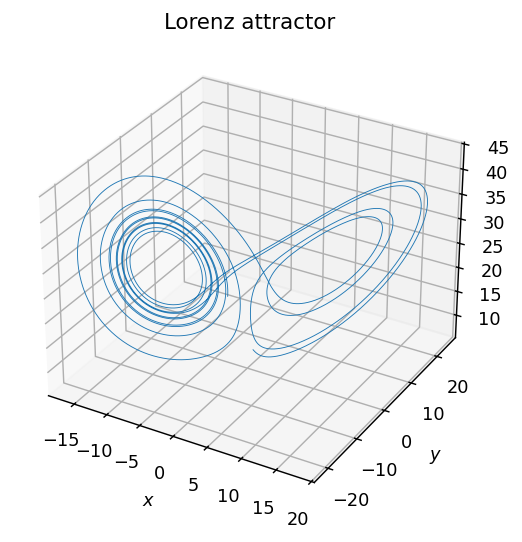

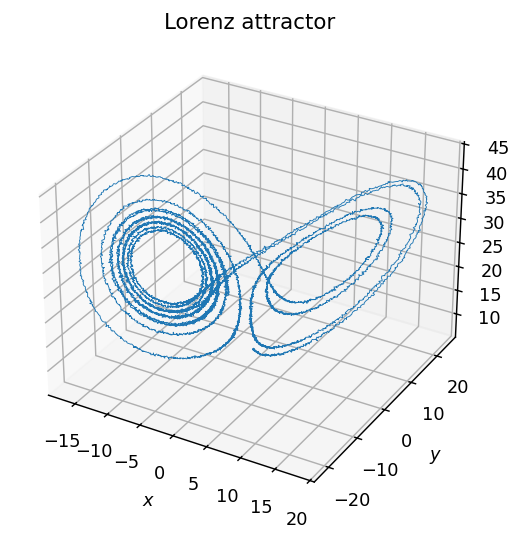

In [ ]:
ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x_noisy, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

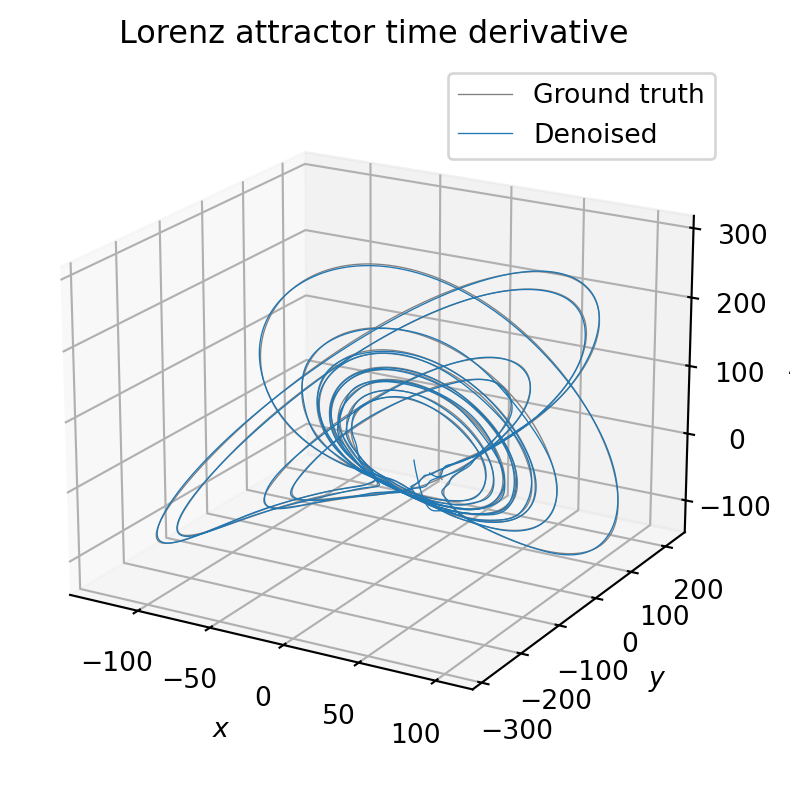

In [ ]:
ax = plt.figure(dpi=192).add_subplot(projection="3d")

ax.plot(*traj.x_dot, lw=0.5, color="0.5")
ax.plot(*traj.x_dot_denoised, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor time derivative")
ax.view_init(elev=20, azim=-60)
ax.legend(["Ground truth", "Denoised"])

plt.show()

In [ ]:
noise_levels = [0, 0.01, 0.05, 0.1, 0.2] #noise levels to test

#Parameters for the system and data generation
dt = 1e-3
num_steps = 2 * 10 ** 3
x_0 = np.array([0, 2, 8])


In [ ]:
#Setting up pysindy
sparsity_threshold = 0.1
stlsq_optimizer = ps.STLSQ(threshold=sparsity_threshold, alpha=0.05) # alpha can be used for additional regularization

# Initialize the SINDy model with the configured optimizer
model = ps.SINDy(optimizer=stlsq_optimizer)

# Define the polynomial library with degree 3
poly_library = ps.PolynomialLibrary(degree=3)

In [ ]:
#Calculate MSE for each noise level
MSEs = []
for i, noise in enumerate(noise_levels):
    traj = mysindy.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise)
    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working

    #Initialize sindy model with polynomial 3
    model_poly3 = ps.SINDy(
      optimizer=stlsq_optimizer,
      feature_library=poly_library
      )
    model_poly3.fit(traj.x_noisy.transpose(), t=dt)
    # Call model.coefficients() to get the coefficient matrix
    xi = model_poly3.coefficients()

    #This is the end of where our sindy implementation differs
    
    lorenz_arr_padded = mysindy.lorenz_array(xi.transpose())
    #print(xi.transpose().shape)
    #print(lorenz_arr_padded.shape)
    MSEs.append(mean_squared_error(xi.transpose(), lorenz_arr_padded))

In [ ]:
ax = plt.figure(dpi=128).add_subplot()
ax.plot(noise_levels, MSEs, marker="o")
ax.set_xlabel("Noise level")
ax.set_ylabel("MSE of identified coefficients")
ax.set_title("MSE of identified coefficients vs noise level")
plt.show()

